# Preprocesamiento y visualizacion del dataset

El objetivo de este notebook es documentar, de forma ordenada y comprensible, el proceso de revision, limpieza y transformacion del dataset de gaming y salud mental. La estructura esta organizada por etapas para que cada decision de preprocesamiento quede justificada y sea facil de seguir en el contexto de una tarea academica.

## 1. Librerias y configuracion

En primer lugar se importan las librerias necesarias para el analisis y se fijan algunos parametros de trabajo. Se utiliza una muestra amplia del dataset para mantener un equilibrio entre representatividad y tiempo de ejecucion.

In [1]:
import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str(Path(".matplotlib").resolve())
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATASET_PATH = Path("Dataset/gaming_mental_health_10M_40features.csv.gz")
SAMPLE_ROWS = 200_000
SAVE_PROCESSED = True
PROCESSED_OUTPUT = Path("dataset_preprocessed_notebook.csv")

## 2. Carga del dataset

En esta etapa se carga el archivo original desde la carpeta `Dataset`. Para facilitar la exploracion inicial, se trabaja con una muestra del conjunto de datos. Si se requiere un analisis completo, el parametro `SAMPLE_ROWS` puede cambiarse a `None`.

In [2]:
df = pd.read_csv(DATASET_PATH, nrows=SAMPLE_ROWS)

print(f"Shape: {df.shape}")
df.head()

Shape: (200000, 39)


,age,gender,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,depression_score,social_interaction_score,relationship_satisfaction,academic_performance,work_productivity,addiction_level,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
0,51,Female,8615,3.68,22,17,5.26,1.00,0.18,3,4.06,5.02,7.85,9.55,68.80,77.12,2.02,0.39,0.05,0.51,0.23,0.32,1.50,20,186,2.82,1,1,1746.97,0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80,10
1,41,Female,39453,5.70,34,16,9.20,0.70,1.44,8,6.76,7.63,7.06,6.96,38.11,44.94,5.85,0.23,0.37,0.43,0.24,0.32,17.93,37,21,1.34,8,1,342.04,7,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57,2
2,27,Male,40466,1.58,8,22,7.39,2.24,3.15,3,9.57,4.02,1.12,2.61,97.44,54.77,0.08,0.06,0.15,0.48,0.27,0.42,2.99,45,146,3.56,8,1,57.95,9,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59,10
3,55,Male,51076,6.11,39,24,7.99,1.65,2.80,1,4.97,1.40,6.59,6.00,67.65,88.56,2.77,0.53,0.36,0.64,0.57,0.82,1.99,11,133,1.80,6,1,617.32,5,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89,1
4,20,Male,86116,3.65,17,0,7.12,1.02,1.01,2,8.73,4.83,6.03,3.54,62.34,68.82,3.37,0.78,0.25,0.29,0.47,0.83,9.23,24,399,1.30,4,0,1398.39,9,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15,10


## 3. Revision inicial

Antes de transformar los datos, es importante conocer su estructura general. Por eso se revisan los tipos de variables, la presencia de valores faltantes y un resumen estadistico basico. Esta revision permite detectar rapidamente posibles problemas de calidad.

In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False)
}).sort_index()

overview

,dtype,missing,unique
academic_performance,float64,0,7504
addiction_level,float64,0,1001
age,int64,0,47
aggression_score,float64,0,1001
anxiety_score,float64,0,1001
back_pain_score,float64,0,1000
bmi,float64,0,2741
caffeine_intake,float64,0,1491
competitive_rank,int64,0,100
daily_gaming_hours,float64,0,1956


In [4]:
numeric_summary = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
numeric_summary[["min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]].round(2)

,min,1%,5%,25%,50%,75%,95%,99%,max
age,13.00,13.00,15.00,24.00,36.00,48.00,57.00,59.00,59.00
income,5000.00,6449.99,12235.00,41171.00,77285.00,113722.00,142641.00,148501.00,149999.00
daily_gaming_hours,0.00,0.30,0.71,1.92,3.36,5.40,9.50,13.34,26.81
weekly_sessions,1.00,1.00,2.00,10.00,20.00,30.00,38.00,39.00,39.00
years_gaming,0.00,0.00,1.00,6.00,12.00,18.00,23.00,24.00,24.00
sleep_hours,0.27,3.51,4.53,5.99,7.00,8.01,9.48,10.50,13.99
caffeine_intake,0.00,0.02,0.10,0.57,1.38,2.77,5.97,9.21,24.10
exercise_hours,0.00,0.02,0.10,0.58,1.38,2.77,5.98,9.26,26.48
stress_level,1.00,1.00,1.00,3.00,5.00,8.00,10.00,10.00,10.00
anxiety_score,0.00,0.33,1.71,3.66,5.01,6.35,8.29,9.66,10.00


## 4. Clasificacion de variables

A continuacion se clasifican las columnas segun su naturaleza: categoricas, binarias, ordinales y continuas. Esta separacion es util porque no todas las variables deben tratarse de la misma forma durante el preprocesamiento.

In [5]:
categorical_columns = ["gender"]
binary_columns = ["headset_usage"]
ordinal_columns = ["stress_level", "esports_interest", "parental_supervision", "internet_quality"]
continuous_columns = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in binary_columns and col not in ordinal_columns
]

column_groups = {
    "categorical": categorical_columns,
    "binary": binary_columns,
    "ordinal": ordinal_columns,
    "continuous": continuous_columns,
}

pd.Series({key: len(value) for key, value in column_groups.items()}, name="n_columns")

categorical     1
binary          1
ordinal         4
continuous     33
Name: n_columns, dtype: int64

## 5. Reglas de validacion

Aunque el dataset no presenta valores faltantes de forma explicita, si contiene observaciones que resultan poco realistas o directamente imposibles. Para enfrentar esto, se definen reglas de validacion por variable, con el fin de identificar valores fuera de rango y tratarlos como faltantes.

In [6]:
INVALID_RULES = {
    "age": (13, 100),
    "income": (0, 1_000_000),
    "daily_gaming_hours": (0, 24),
    "weekly_sessions": (0, 7 * 24),
    "years_gaming": (0, 80),
    "sleep_hours": (0, 24),
    "caffeine_intake": (0, 50),
    "exercise_hours": (0, 24),
    "stress_level": (1, 10),
    "anxiety_score": (0, 10),
    "depression_score": (0, 10),
    "social_interaction_score": (0, 10),
    "relationship_satisfaction": (0, 10),
    "academic_performance": (0, 100),
    "work_productivity": (0, 100),
    "addiction_level": (0, 10),
    "multiplayer_ratio": (0, 1),
    "toxic_exposure": (0, 1),
    "violent_games_ratio": (0, 1),
    "mobile_gaming_ratio": (0, 1),
    "night_gaming_ratio": (0, 1),
    "weekend_gaming_hours": (0, 72),
    "friends_gaming_count": (0, 10_000),
    "online_friends": (0, 100_000),
    "streaming_hours": (0, 24),
    "esports_interest": (0, 10),
    "headset_usage": (0, 1),
    "microtransactions_spending": (0, 1_000_000),
    "parental_supervision": (0, 10),
    "loneliness_score": (0, 10),
    "aggression_score": (0, 10),
    "happiness_score": (0, 10),
    "bmi": (10, 70),
    "screen_time_total": (0, 24),
    "eye_strain_score": (0, 10),
    "back_pain_score": (0, 10),
    "competitive_rank": (0, 100),
    "internet_quality": (1, 10),
}

invalid_counts = {}
for column, (lower, upper) in INVALID_RULES.items():
    if column in df.columns:
        mask = df[column].notna() & ((df[column] < lower) | (df[column] > upper))
        invalid_counts[column] = int(mask.sum())

pd.Series(invalid_counts).sort_values(ascending=False).to_frame("invalid_count")

,invalid_count
screen_time_total,475
bmi,39
daily_gaming_hours,12
exercise_hours,1
income,0
age,0
sleep_hours,0
years_gaming,0
weekly_sessions,0
caffeine_intake,0


## 6. Limpieza de valores invalidos

Una vez definidas las reglas, los valores que no cumplen con los rangos esperados se reemplazan por `NaN`. Esta decision permite conservar la observacion, pero sin arrastrar informacion incorrecta hacia el analisis posterior.

In [7]:
df_clean = df.copy()

for column, (lower, upper) in INVALID_RULES.items():
    if column in df_clean.columns:
        mask = df_clean[column].notna() & ((df_clean[column] < lower) | (df_clean[column] > upper))
        df_clean.loc[mask, column] = np.nan

df_clean.isna().sum().sort_values(ascending=False).head(15).to_frame("missing_after_cleaning")

,missing_after_cleaning
screen_time_total,475
bmi,39
daily_gaming_hours,12
exercise_hours,1
income,0
gender,0
age,0
sleep_hours,0
years_gaming,0
weekly_sessions,0


## 7. Tratamiento de outliers

Despues de corregir los valores invalidos, se revisan las variables con distribuciones muy sesgadas o con extremos marcados. En estos casos se aplica winsorizacion por percentiles, lo que reduce la influencia de valores atipicos sin eliminar registros completos.

In [8]:
skewed_columns = [
    "microtransactions_spending",
    "screen_time_total",
    "daily_gaming_hours",
    "weekend_gaming_hours",
    "caffeine_intake",
    "exercise_hours",
]

clip_summary = []
for column in skewed_columns:
    if column in df_clean.columns:
        lower = df_clean[column].quantile(0.01)
        upper = df_clean[column].quantile(0.99)
        below = int((df_clean[column] < lower).sum())
        above = int((df_clean[column] > upper).sum())
        df_clean[column] = df_clean[column].clip(lower=lower, upper=upper)
        clip_summary.append({
            "column": column,
            "lower_clip": round(float(lower), 3),
            "upper_clip": round(float(upper), 3),
            "clipped_low": below,
            "clipped_high": above,
        })

pd.DataFrame(clip_summary)

,column,lower_clip,upper_clip,clipped_low,clipped_high
0,microtransactions_spending,4.91,2296.581,1997,2000
1,screen_time_total,1.66,19.460,1990,1989
2,daily_gaming_hours,0.30,13.330,1964,1989
3,weekend_gaming_hours,0.45,19.950,1982,1998
4,caffeine_intake,0.02,9.210,1469,1999
5,exercise_hours,0.02,9.260,1432,1995


## 8. Variables derivadas

Ademas de las variables originales, se construyen algunos indicadores compuestos que resumen dimensiones relevantes del problema, como la intensidad de juego, la proporcion de interaccion social en linea y una medida agregada de carga mental.

In [9]:
df_clean["gaming_intensity_index"] = (
    df_clean["daily_gaming_hours"].fillna(0) * 5 + df_clean["weekend_gaming_hours"].fillna(0)
) / 7

df_clean["online_social_ratio"] = df_clean["online_friends"] / (df_clean["friends_gaming_count"] + 1)
df_clean["gaming_screen_share"] = df_clean["daily_gaming_hours"] / (df_clean["screen_time_total"] + 1e-6)
df_clean["mental_burden_index"] = (
    df_clean["anxiety_score"] + df_clean["depression_score"] + df_clean["stress_level"]
) / 3

df_clean[[
    "gaming_intensity_index",
    "online_social_ratio",
    "gaming_screen_share",
    "mental_burden_index",
]].describe().round(2)

,gaming_intensity_index,online_social_ratio,gaming_screen_share,mental_burden_index
count,200000.00,200000.00,199525.00,200000.00
mean,3.70,22.39,0.50,5.17
std,2.04,46.73,0.22,1.41
min,0.23,0.00,0.02,0.33
25%,2.18,4.86,0.32,4.17
50%,3.29,9.76,0.50,5.17
75%,4.79,19.14,0.67,6.16
max,12.37,499.00,1.00,10.00


## 9. Imputacion y codificacion

Para finalizar el preprocesamiento, los valores faltantes numericos se imputan mediante la mediana, ya que es una medida robusta frente a distribuciones asimetricas. Luego, la variable `gender` se transforma con codificacion one-hot para dejar el conjunto de datos preparado para analisis estadistico o modelado.

In [10]:
df_model = df_clean.copy()

numeric_columns = df_model.select_dtypes(include=[np.number]).columns
for column in numeric_columns:
    if df_model[column].isna().any():
        df_model[column] = df_model[column].fillna(df_model[column].median())

df_model = pd.get_dummies(df_model, columns=["gender"], prefix="gender", dtype=int)

print(df_model.shape)
df_model.head()

(200000, 45)


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,depression_score,social_interaction_score,relationship_satisfaction,academic_performance,work_productivity,addiction_level,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality,gaming_intensity_index,online_social_ratio,gaming_screen_share,mental_burden_index,gender_Female,gender_Male,gender_Other
0,51.0,8615.0,3.68,22.0,17.0,5.26,1.00,0.18,3.0,4.06,5.02,7.85,9.55,68.80,77.12,2.02,0.39,0.05,0.51,0.23,0.32,1.50,20.0,186.0,2.82,1.0,1.0,1746.97,0.0,2.87,3.19,5.20,19.69,4.71,5.71,4.81,80.0,10.0,2.842857,8.857143,0.781316,4.026667,1,0,0
1,41.0,39453.0,5.70,34.0,16.0,9.20,0.70,1.44,8.0,6.76,7.63,7.06,6.96,38.11,44.94,5.85,0.23,0.37,0.43,0.24,0.32,17.93,37.0,21.0,1.34,8.0,1.0,342.04,7.0,4.17,7.73,5.40,26.37,6.62,6.77,3.99,57.0,2.0,6.632857,0.552632,0.861027,7.463333,1,0,0
2,27.0,40466.0,1.58,8.0,22.0,7.39,2.24,3.15,3.0,9.57,4.02,1.12,2.61,97.44,54.77,0.08,0.06,0.15,0.48,0.27,0.42,2.99,45.0,146.0,3.56,8.0,1.0,57.95,9.0,9.38,2.85,5.17,25.15,9.30,2.16,4.75,59.0,10.0,1.555714,3.173913,0.169892,5.530000,0,1,0
3,55.0,51076.0,6.11,39.0,24.0,7.99,1.65,2.80,1.0,4.97,1.40,6.59,6.00,67.65,88.56,2.77,0.53,0.36,0.64,0.57,0.82,1.99,11.0,133.0,1.80,6.0,1.0,617.32,5.0,8.24,7.19,8.62,26.42,13.81,4.72,5.37,89.0,1.0,4.648571,11.083333,0.442433,2.456667,0,1,0
4,20.0,86116.0,3.65,17.0,0.0,7.12,1.02,1.01,2.0,8.73,4.83,6.03,3.54,62.34,68.82,3.37,0.78,0.25,0.29,0.47,0.83,9.23,24.0,399.0,1.30,4.0,0.0,1398.39,9.0,6.65,2.53,9.71,25.75,10.74,3.90,6.44,15.0,10.0,3.925714,15.960000,0.339851,5.186667,0,1,0


## 10. Graficos relevantes para el analisis

En esta seccion no se busca mostrar todos los graficos posibles, sino aquellos que aportan informacion clara para una primera interpretacion del dataset. Se priorizan visualizaciones que permitan describir la muestra y explorar relaciones entre juego, bienestar y salud mental.

### 10.1 Distribucion general de la muestra

El primer grafico resume dos aspectos basicos del conjunto de datos: la composicion por genero y la distribucion etaria. Esta visualizacion permite describir rapidamente a la poblacion observada antes de entrar en relaciones mas especificas.

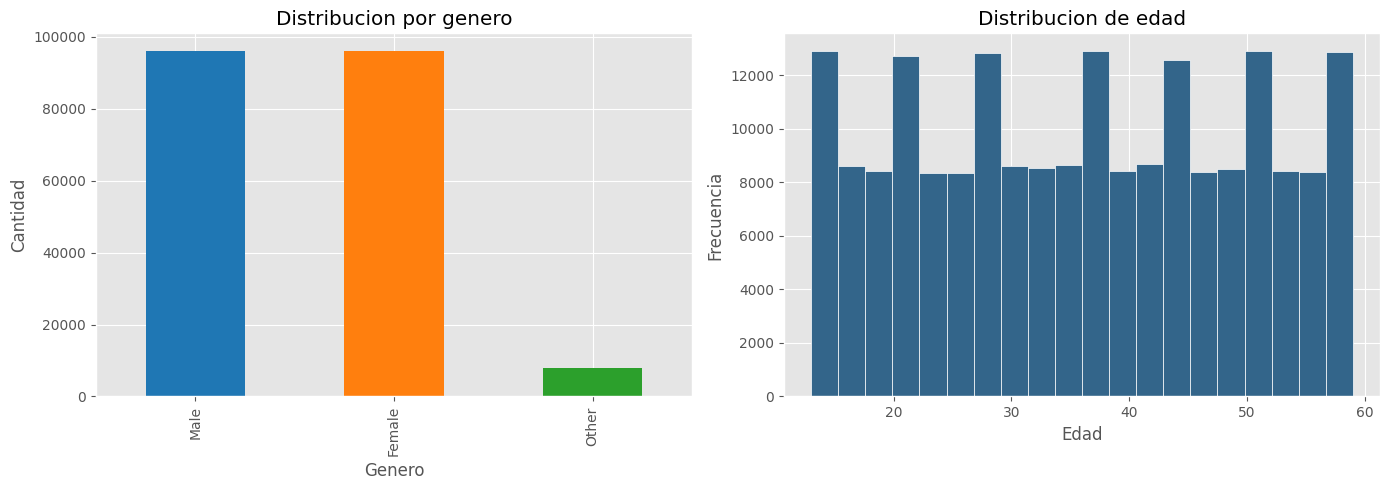

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["gender"].value_counts().plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0].set_title("Distribucion por genero")
axes[0].set_xlabel("Genero")
axes[0].set_ylabel("Cantidad")

axes[1].hist(df["age"], bins=20, color="#33658a", edgecolor="white")
axes[1].set_title("Distribucion de edad")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### 10.2 Distribucion de variables de salud mental

A continuacion se observan cuatro puntajes centrales del dataset. Este paso sirve para identificar si las distribuciones parecen equilibradas, concentradas en ciertos rangos o sesgadas hacia valores extremos.

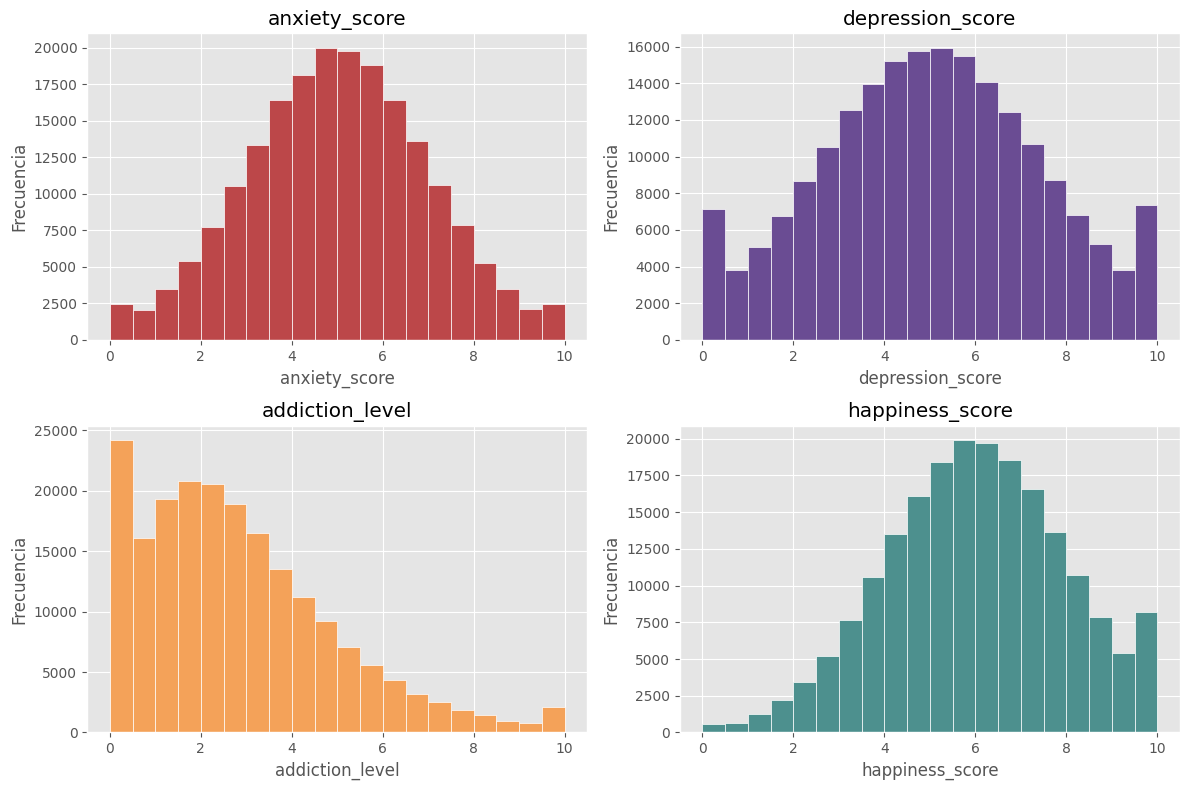

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
score_columns = ["anxiety_score", "depression_score", "addiction_level", "happiness_score"]
score_colors = ["#bc4749", "#6a4c93", "#f4a259", "#4d908e"]

for ax, column, color in zip(axes.flat, score_columns, score_colors):
    ax.hist(df_clean[column], bins=20, color=color, edgecolor="white")
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### 10.3 Relacion entre horas de juego y nivel de adiccion

Este grafico permite evaluar si existe una tendencia general entre el tiempo diario de juego y el nivel de adiccion reportado. Se utiliza una muestra de puntos para facilitar la lectura y se agrega una linea de tendencia como apoyo visual.

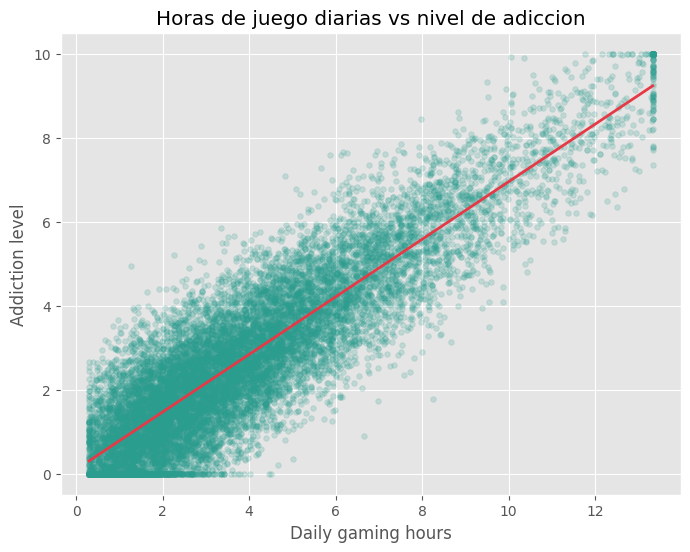

In [13]:
scatter_df = df_clean[["daily_gaming_hours", "addiction_level"]].dropna().sample(15000, random_state=42)
x = scatter_df["daily_gaming_hours"].to_numpy()
y = scatter_df["addiction_level"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2, s=16, color="#2a9d8f")
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, slope * x_line + intercept, color="#e63946", linewidth=2)
plt.title("Horas de juego diarias vs nivel de adiccion")
plt.xlabel("Daily gaming hours")
plt.ylabel("Addiction level")
plt.show()

### 10.4 Correlaciones entre variables relevantes

El mapa de correlacion resume la intensidad y direccion de las asociaciones lineales entre variables seleccionadas. No implica causalidad, pero resulta util para detectar patrones consistentes y posibles grupos de variables relacionadas.

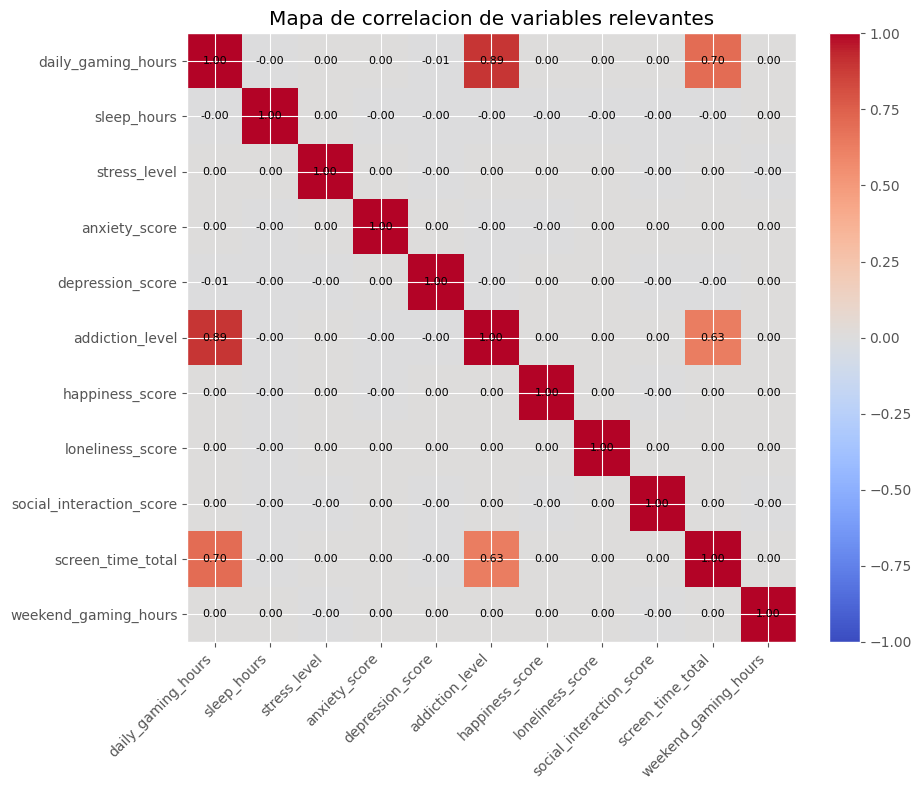

In [14]:
heatmap_columns = [
    "daily_gaming_hours",
    "sleep_hours",
    "stress_level",
    "anxiety_score",
    "depression_score",
    "addiction_level",
    "happiness_score",
    "loneliness_score",
    "social_interaction_score",
    "screen_time_total",
    "weekend_gaming_hours",
]

corr = df_clean[heatmap_columns].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Mapa de correlacion de variables relevantes")

for row in range(corr.shape[0]):
    for col in range(corr.shape[1]):
        plt.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 10.5 Variables mas asociadas con `addiction_level`

Finalmente, se muestran las variables con mayor correlacion absoluta respecto de `addiction_level`. Esta visualizacion ayuda a priorizar que atributos conviene revisar con mayor detalle en un analisis posterior o en una etapa de modelado.

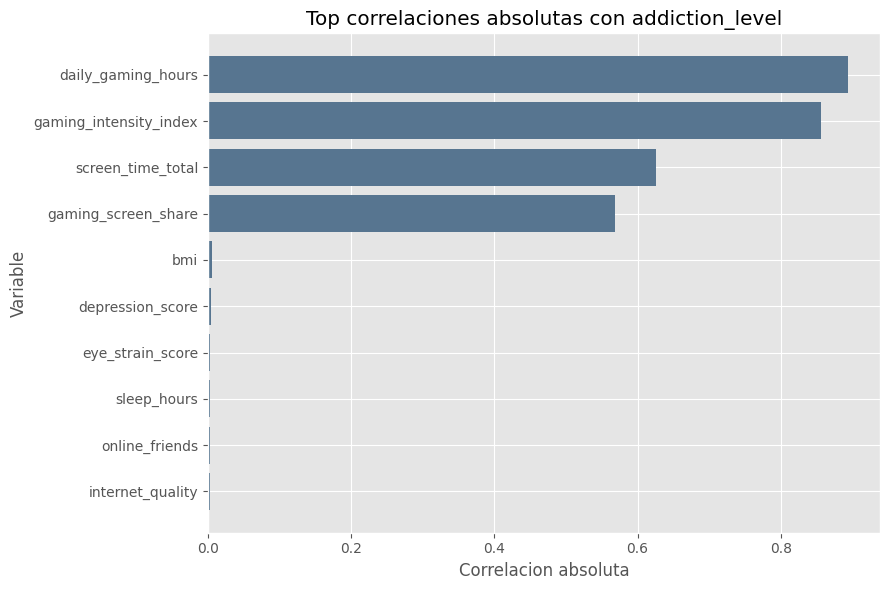

In [15]:
top_corr = df_clean.corr(numeric_only=True)["addiction_level"].drop("addiction_level").abs().sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_corr.index, top_corr.values, color="#577590")
plt.title("Top correlaciones absolutas con addiction_level")
plt.xlabel("Correlacion absoluta")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 11. Guardado opcional del dataset procesado

La siguiente celda exporta una version limpia y transformada del dataset. Este archivo puede utilizarse como insumo para nuevos analisis o como base para construir modelos predictivos.

In [ ]:
if SAVE_PROCESSED:
    df_model.to_csv(PROCESSED_OUTPUT, index=False)
    print(f"Archivo guardado en: {PROCESSED_OUTPUT.resolve()}")
else:
    print("Guardado desactivado")

## 12. Conclusiones

A traves de este notebook se desarrollo un flujo de preprocesamiento claro y reproducible, compuesto por revision inicial, validacion de rangos, tratamiento de outliers, generacion de variables derivadas e imputacion de faltantes. Ademas, se incorporaron visualizaciones orientadas a describir la muestra y explorar relaciones entre intensidad de juego y variables de salud mental.

Como siguiente paso, si el objetivo del trabajo incluye modelado predictivo, seria recomendable encapsular este procedimiento en un `Pipeline` de `scikit-learn` para separar correctamente entrenamiento y prueba, y asi evitar fuga de informacion.